In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)

In [2]:
ROOT = Path.cwd()
HM_PATH = ROOT / "Hackmageddon_Attacks" / "NoI_monthly_v2.csv"
csis_candidates = sorted((ROOT / "CSIS").glob("csis_output_*.csv"), key=lambda p: p.stat().st_mtime)

# prefer outputs generated by vcdb_simplify.py in hackmageddon-compatible modes
vcdb_patterns = [
    "vcdb_hackmageddon_*.csv",
    "vcdb_enhanced_*.csv",
    "vcdb_vcdb_mapped_*.csv",
    "vcdb_original_attacks.csv",
    "vcdb_output_*.csv",
]
vcdb_candidates = []
for pattern in vcdb_patterns:
    vcdb_candidates.extend((ROOT / "VCDB").glob(pattern))
vcdb_candidates = sorted(set(vcdb_candidates), key=lambda p: p.stat().st_mtime)

if not HM_PATH.exists():
    raise FileNotFoundError(f"Missing file: {HM_PATH}")
if not csis_candidates:
    raise FileNotFoundError("No csis_output_*.csv files found in CSIS folder.")
if not vcdb_candidates:
    raise FileNotFoundError(
        "No VCDB output file found. Run vcdb_simplify.py in hackmageddon/enhanced/vcdb_mapped mode first."
    )

CSIS_PATH = csis_candidates[-1]
VCDB_PATH = vcdb_candidates[-1]

hm_raw = pd.read_csv(HM_PATH)
csis_raw = pd.read_csv(CSIS_PATH)
vcdb_raw = pd.read_csv(VCDB_PATH)

print("Hackmageddon file:", HM_PATH)
print("CSIS file        :", CSIS_PATH)
print("VCDB file        :", VCDB_PATH)
print("\nHackmageddon columns:", list(hm_raw.columns[:8]), "...")
print("CSIS columns        :", list(csis_raw.columns[:8]), "...")
print("VCDB columns        :", list(vcdb_raw.columns[:8]), "...")


required_first_cols = {"Attack-Country", "Period"}
assert hm_raw.columns[0] in required_first_cols, "Hackmageddon file must start with Attack-Country or Period."
assert csis_raw.columns[0] in required_first_cols, "CSIS file must start with Attack-Country or Period."
assert vcdb_raw.columns[0] in required_first_cols, "VCDB file must start with Attack-Country or Period."

Hackmageddon file: c:\Users\Benjamin\Documents\MEGA\MEGA\RMIT\2026\NATO\Cyber-trend-forecasting\Data_Preparation\Hackmageddon_Attacks\NoI_monthly_v2.csv
CSIS file        : c:\Users\Benjamin\Documents\MEGA\MEGA\RMIT\2026\NATO\Cyber-trend-forecasting\Data_Preparation\CSIS\csis_output_20260328-02.csv
VCDB file        : c:\Users\Benjamin\Documents\MEGA\MEGA\RMIT\2026\NATO\Cyber-trend-forecasting\Data_Preparation\VCDB\vcdb_enhanced_20260328-01.csv

Hackmageddon columns: ['Attack-Country', 'DDoS-US', 'DDoS-GB', 'DDoS-CA', 'DDoS-AU', 'DDoS-UA', 'DDoS-RU', 'DDoS-FR'] ...
CSIS columns        : ['Period', 'DDoS-US', 'DDoS-GB', 'DDoS-CA', 'DDoS-AU', 'DDoS-UA', 'DDoS-RU', 'DDoS-FR'] ...
VCDB columns        : ['Period', 'DDoS-US', 'DDoS-GB', 'DDoS-CA', 'DDoS-AU', 'DDoS-UA', 'DDoS-RU', 'DDoS-FR'] ...


In [3]:
def to_attack_country_matrix(df: pd.DataFrame) -> pd.DataFrame:
    """Convert input to matrix: index=Attack-Country, cols=periods.

    Handles both orientations, including files whose first column name is
    'Attack-Country' but whose values are period labels (transposed output).
    """
    first_col = df.columns[0]
    if first_col not in {"Attack-Country", "Period"}:
        raise ValueError(f"Unsupported first column: {first_col}")

    id_values = df[first_col].astype(str).str.strip()
    period_like = id_values.str.match(r"^\d{2}/\d{4}$", na=False)

    # If ID column is 'Period' OR the ID values look like periods, file is transposed.
    if first_col == "Period" or period_like.mean() > 0.5:
        mat = df.set_index(first_col).T
        mat.index.name = "Attack-Country"
    else:
        mat = df.set_index(first_col)

    mat = mat.apply(pd.to_numeric, errors="coerce").fillna(0)
    return mat


def parse_attack_country(index: pd.Index) -> pd.DataFrame:
    s = pd.Series(index.astype(str), index=index)
    parts = s.str.rsplit("-", n=1, expand=True)
    if parts.shape[1] != 2:
        raise ValueError(
            "Could not parse Attack-Country labels. "
            "Check whether the source file orientation was detected correctly."
        )

    out = pd.DataFrame(index=index)
    out["attack"] = parts[0].str.strip()
    out["country"] = parts[1].str.strip()

    attack_alias = {
        "advanced persistent threat": "Advanced persistent threat",
        "ddos": "DDoS",
        "zero day": "Zero-day"
    }
    out["attack"] = out["attack"].str.replace("_", " ", regex=False)
    out["attack"] = out["attack"].replace(attack_alias)
    out["attack"] = out["attack"].fillna("Unknown")

    country_alias = {
        "UK": "GB",
        "UNK": "?",
        "UNKNOWN": "?",
        "": "?"
    }
    out["country"] = out["country"].replace(country_alias).fillna("?")

    return out

In [4]:
hm_matrix = to_attack_country_matrix(hm_raw)
csis_matrix = to_attack_country_matrix(csis_raw)
vcdb_matrix = to_attack_country_matrix(vcdb_raw)

hm_meta = parse_attack_country(hm_matrix.index)
csis_meta = parse_attack_country(csis_matrix.index)
vcdb_meta = parse_attack_country(vcdb_matrix.index)

hm_totals = hm_matrix.sum(axis=1)
csis_totals = csis_matrix.sum(axis=1)
vcdb_totals = vcdb_matrix.sum(axis=1)

hm_attack_counts = hm_totals.groupby(hm_meta["attack"]).sum().sort_values(ascending=False)
hm_country_counts = hm_totals.groupby(hm_meta["country"]).sum().sort_values(ascending=False)

csis_attack_counts = csis_totals.groupby(csis_meta["attack"]).sum().sort_values(ascending=False)
csis_country_counts = csis_totals.groupby(csis_meta["country"]).sum().sort_values(ascending=False)

vcdb_attack_counts = vcdb_totals.groupby(vcdb_meta["attack"]).sum().sort_values(ascending=False)
vcdb_country_counts = vcdb_totals.groupby(vcdb_meta["country"]).sum().sort_values(ascending=False)

print("Total attacks:")
print("Hackmageddon:", hm_totals.sum())
print("CSIS:", csis_totals.sum())
print("VCDB:", vcdb_totals.sum())

print("\nTop Hackmageddon attacks:")
display(hm_attack_counts.head(10).to_frame("count"))
print("Top CSIS attacks:")
display(csis_attack_counts.head(10).to_frame("count"))
print("Top VCDB attacks:")
display(vcdb_attack_counts.head(10).to_frame("count"))

print("Top Hackmageddon countries:")
display(hm_country_counts.head(10).to_frame("count"))
print("Top CSIS countries:")
display(csis_country_counts.head(10).to_frame("count"))
print("Top VCDB countries:")
display(vcdb_country_counts.head(10).to_frame("count"))

Total attacks:
Hackmageddon: 701096.0
CSIS: 4664
VCDB: 10702

Top Hackmageddon attacks:


,count
attack,
Malware,258318.0
Account Hijacking,49576.0
Vulnerability,48696.0
Phishing,47490.0
Targeted Attack,45836.0
Ransomware,43700.0
Others,35332.0
Data Breach,27776.0
Trojan,24260.0


Top CSIS attacks:


,count
attack,
Others,920
Malware,848
Data Breach,716
Targeted Attack,434
Advanced persistent threat,262
Vulnerability,216
Ransomware,180
Phishing,174
DDoS,166


Top VCDB attacks:


...

,count
country,
ALL,350548.0
US,23865.0
GB,10320.0
?,10038.0
IT,9712.0
CA,9443.0
IN,9435.0
FR,9420.0
RU,9373.0


Top CSIS countries:


,count
country,
ALL,2332
?,478
US,286
IN,74
UA,74
GB,73
DE,65
IL,64
IR,61


Top VCDB countries:


,count
country,
ALL,5351
US,3873
?,409
GB,274
CA,181
AU,96
IN,71
IE,46
IL,45


In [5]:
hm_attack_counts

attack
Malware                          258318.0
Account Hijacking                 49576.0
Vulnerability                     48696.0
Phishing                          47490.0
Targeted Attack                   45836.0
Ransomware                        43700.0
Others                            35332.0
Data Breach                       27776.0
Trojan                            24260.0
Botnet                            20614.0
Backdoor                          17104.0
Unknown                           13660.0
Password Attack                   13566.0
Zero-day                           9112.0
DDoS                               9104.0
Malvertising                       8478.0
Spyware                            4476.0
SQL Injection                      4238.0
Brute Force Attack                 3852.0
Worms                              3356.0
Cryptojacking                      3200.0
Defacement                         2908.0
Adware                             2776.0
Disinformation/Misinformati

In [6]:
csis_attack_counts

attack
Others                           920
Malware                          848
Data Breach                      716
Targeted Attack                  434
Advanced persistent threat       262
Vulnerability                    216
Ransomware                       180
Phishing                         174
DDoS                             166
Password Attack                  162
Spyware                          112
Backdoor                         100
Trojan                            90
Botnet                            82
Brute Force Attack                76
Unknown                           62
Disinformation/Misinformation     28
Zero-day                          14
Defacement                        10
Account Hijacking                  6
Worms                              4
SQL Injection                      2
Cryptojacking                      0
Adware                             0
Malvertising                       0
XSS                                0
dtype: int64

In [7]:
vcdb_attack_counts

attack
Others                           4244
Data Breach                      2532
Malware                           806
Advanced persistent threat        712
Password Attack                   490
Ransomware                        368
DDoS                              298
Defacement                        296
Phishing                          266
Vulnerability                     200
Unknown                           188
SQL Injection                      80
Zero-day                           52
Brute Force Attack                 42
Backdoor                           38
Targeted Attack                    30
Trojan                             24
Botnet                             10
XSS                                 6
Spyware                             4
Adware                              4
Disinformation/Misinformation       4
Worms                               4
Account Hijacking                   2
Cryptojacking                       2
Malvertising                        0
dtype

In [8]:
# normalise country distributions

hm_country_norm = hm_country_counts.drop(labels=["ALL"], errors="ignore")
csis_country_norm = csis_country_counts.drop(labels=["ALL"], errors="ignore")

hm_country_norm = hm_country_norm / hm_country_norm.sum()
csis_country_norm = csis_country_norm / csis_country_norm.sum()

all_countries = sorted(set(hm_country_norm.index) | set(csis_country_norm.index))
country_compare = pd.DataFrame({
    "HM_share": hm_country_norm.reindex(all_countries, fill_value=0),
    "CSIS_share": csis_country_norm.reindex(all_countries, fill_value=0)
})
country_compare["abs_diff"] = (country_compare["HM_share"] - country_compare["CSIS_share"]).abs()
country_compare["rel_diff"] = country_compare["abs_diff"] / country_compare[["HM_share", "CSIS_share"]].max(axis=1).replace(0, np.nan)

country_compare.sort_values("abs_diff", ascending=False).head(15)

,HM_share,CSIS_share,abs_diff,rel_diff
country,,,,
?,0.028635,0.204974,0.176339,0.860299
US,0.068079,0.122642,0.054562,0.444893
PT,0.025249,0.012436,0.012813,0.507479
MY,0.024989,0.012436,0.012554,0.502363
IE,0.025229,0.012864,0.012365,0.490092
AT,0.025141,0.012864,0.012276,0.488299
EG,0.024972,0.012864,0.012108,0.484850
SY,0.024995,0.013293,0.011702,0.468164
CH,0.025383,0.013722,0.011661,0.459399


In [9]:
# normalise attacks
hm_attack_norm = hm_attack_counts / hm_attack_counts.sum()
csis_attack_norm = csis_attack_counts / csis_attack_counts.sum()

all_attacks = sorted(set(hm_attack_norm.index) | set(csis_attack_norm.index))
attack_compare = pd.DataFrame({
    "HM_share": hm_attack_norm.reindex(all_attacks, fill_value=0),
    "CSIS_share": csis_attack_norm.reindex(all_attacks, fill_value=0)
})
attack_compare["abs_diff"] = (attack_compare["HM_share"] - attack_compare["CSIS_share"]).abs()
attack_compare["rel_diff"] = attack_compare["abs_diff"] / attack_compare[["HM_share", "CSIS_share"]].max(axis=1).replace(0, np.nan)

attack_compare.sort_values("abs_diff", ascending=False).head(15)

,HM_share,CSIS_share,abs_diff,rel_diff
attack,,,,
Malware,0.368449,0.181818,0.186631,0.506531
Others,0.050395,0.197256,0.146860,0.744517
Data Breach,0.039618,0.153516,0.113898,0.741930
Account Hijacking,0.070712,0.001286,0.069426,0.981807
Advanced persistent threat,0.001680,0.056175,0.054495,0.970089
Phishing,0.067737,0.037307,0.030430,0.449235
Targeted Attack,0.065378,0.093053,0.027676,0.297416
Ransomware,0.062331,0.038593,0.023737,0.380830
Vulnerability,0.069457,0.046312,0.023145,0.333225


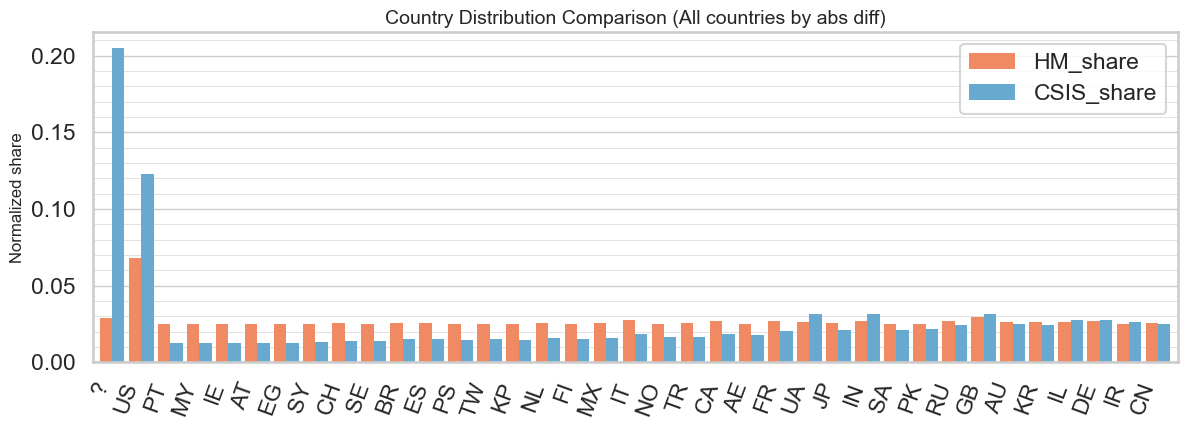

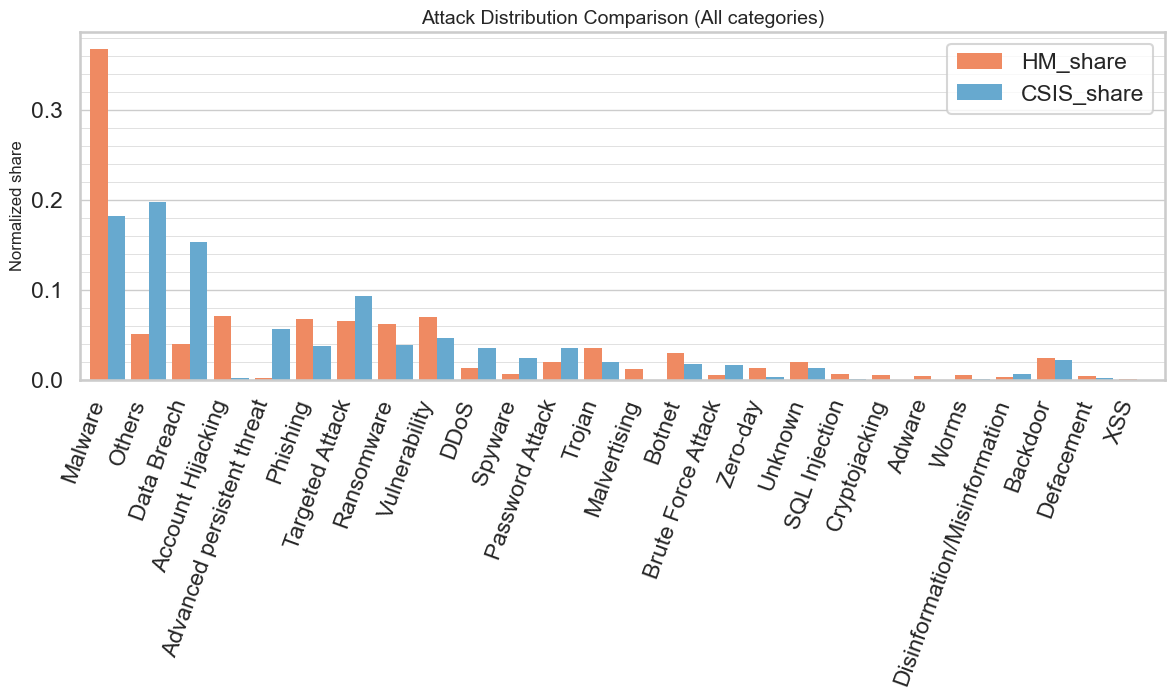

In [10]:
def grouped_bar(df, title, top_n=20, log_scale=False, base_figsize=(14, 5)):
    plot_df = df.sort_values("abs_diff", ascending=False).head(top_n).copy()
    plot_df = plot_df[["HM_share", "CSIS_share"]]

    # Estimate layout needs from the longest category label.
    labels = [str(i) for i in plot_df.index]
    max_label_len = max((len(lbl) for lbl in labels), default=0)

    # Add vertical room for long rotated labels so the axes area stays usable.
    extra_height = min(4.0, max(0.0, (max_label_len - 12) * 0.08))
    fig_width, fig_height = base_figsize
    fig, ax = plt.subplots(figsize=(fig_width, fig_height + extra_height))

    plot_df.plot(
        kind="bar",
        ax=ax,
        width=0.85,
        color=["#ef8a62", "#67a9cf"],
        edgecolor="none",
        linewidth=0
    )
    ax.set_title(title)
    ax.set_ylabel("Normalized share")
    ax.set_xlabel("")
    if log_scale:
        ax.set_yscale("log")
        ax.set_title(title + " (log scale)")

    # Keep only horizontal gridlines, with major + minor (sublines).
    ax.grid(False)
    ax.grid(axis="y", which="major", color="#cccccc", linewidth=1.0)
    ax.minorticks_on()
    ax.grid(axis="y", which="minor", color="#cccccc", linewidth=0.6, alpha=0.7)
    ax.grid(axis="x", which="both", visible=False)

    plt.xticks(rotation=70, ha="right")

    # Grow bottom margin with label length so text is not clipped.
    bottom_margin = min(0.55, 0.22 + max(0.0, (max_label_len - 10) * 0.006))
    fig.subplots_adjust(bottom=bottom_margin)

    plt.show()


grouped_bar(country_compare, "Country Distribution Comparison (All countries by abs diff)", top_n=1000)
grouped_bar(attack_compare, "Attack Distribution Comparison (All categories)", top_n=len(attack_compare))

In [11]:
# recompute normalized comparisons with HM + CSIS + VCDB

hm_country_norm = hm_country_counts.drop(labels=["ALL"], errors="ignore")
csis_country_norm = csis_country_counts.drop(labels=["ALL"], errors="ignore")
vcdb_country_norm = vcdb_country_counts.drop(labels=["ALL"], errors="ignore")

hm_country_norm = hm_country_norm / hm_country_norm.sum()
csis_country_norm = csis_country_norm / csis_country_norm.sum()
vcdb_country_norm = vcdb_country_norm / vcdb_country_norm.sum()

all_countries = sorted(set(hm_country_norm.index) | set(csis_country_norm.index) | set(vcdb_country_norm.index))
country_compare = pd.DataFrame({
    "HM_share": hm_country_norm.reindex(all_countries, fill_value=0),
    "CSIS_share": csis_country_norm.reindex(all_countries, fill_value=0),
    "VCDB_share": vcdb_country_norm.reindex(all_countries, fill_value=0),
})

country_share_cols = ["HM_share", "CSIS_share", "VCDB_share"]
country_compare["abs_diff"] = country_compare[country_share_cols].max(axis=1) - country_compare[country_share_cols].min(axis=1)
country_compare["rel_diff"] = country_compare["abs_diff"] / country_compare[country_share_cols].max(axis=1).replace(0, np.nan)


hm_attack_norm = hm_attack_counts / hm_attack_counts.sum()
csis_attack_norm = csis_attack_counts / csis_attack_counts.sum()
vcdb_attack_norm = vcdb_attack_counts / vcdb_attack_counts.sum()

all_attacks = sorted(set(hm_attack_norm.index) | set(csis_attack_norm.index) | set(vcdb_attack_norm.index))
attack_compare = pd.DataFrame({
    "HM_share": hm_attack_norm.reindex(all_attacks, fill_value=0),
    "CSIS_share": csis_attack_norm.reindex(all_attacks, fill_value=0),
    "VCDB_share": vcdb_attack_norm.reindex(all_attacks, fill_value=0),
})

attack_share_cols = ["HM_share", "CSIS_share", "VCDB_share"]
attack_compare["abs_diff"] = attack_compare[attack_share_cols].max(axis=1) - attack_compare[attack_share_cols].min(axis=1)
attack_compare["rel_diff"] = attack_compare["abs_diff"] / attack_compare[attack_share_cols].max(axis=1).replace(0, np.nan)

print("Top country differences (HM, CSIS, VCDB):")
display(country_compare.sort_values("abs_diff", ascending=False).head(15))
print("Top attack differences (HM, CSIS, VCDB):")
display(attack_compare.sort_values("abs_diff", ascending=False).head(15))

Top country differences (HM, CSIS, VCDB):


,HM_share,CSIS_share,VCDB_share,abs_diff,rel_diff
country,,,,,
US,0.068079,0.122642,0.723790,0.655711,0.905941
?,0.028635,0.204974,0.076434,0.176339,0.860299
UA,0.026573,0.031732,0.002616,0.029116,0.917550
IT,0.027705,0.018439,0.000561,0.027145,0.979764
IR,0.025086,0.026158,0.000748,0.025410,0.971423
PT,0.025249,0.012436,0.000000,0.025249,1.000000
NO,0.025169,0.016295,0.000374,0.024795,0.985150
RU,0.026738,0.024443,0.002056,0.024682,0.923118
KP,0.024687,0.014580,0.000187,0.024500,0.992430


Top attack differences (HM, CSIS, VCDB):


,HM_share,CSIS_share,VCDB_share,abs_diff,rel_diff
attack,,,,,
Others,0.050395,0.197256,0.396561,0.346166,0.872919
Malware,0.368449,0.181818,0.075313,0.293136,0.795594
Data Breach,0.039618,0.153516,0.236591,0.196973,0.832547
Targeted Attack,0.065378,0.093053,0.002803,0.090250,0.969875
Account Hijacking,0.070712,0.001286,0.000187,0.070525,0.997357
Advanced persistent threat,0.001680,0.056175,0.066530,0.064849,0.974745
Vulnerability,0.069457,0.046312,0.018688,0.050769,0.730940
Phishing,0.067737,0.037307,0.024855,0.042882,0.633063
Trojan,0.034603,0.019297,0.002243,0.032360,0.935191


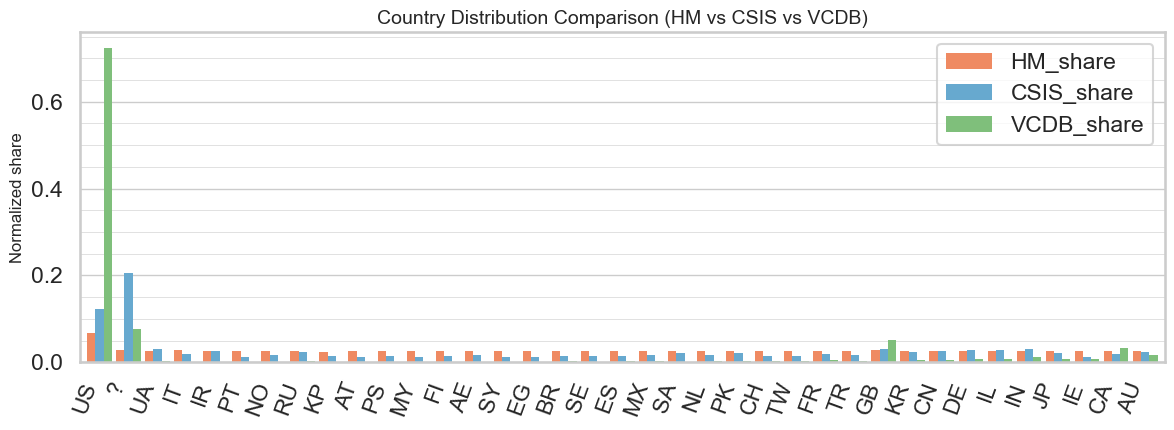

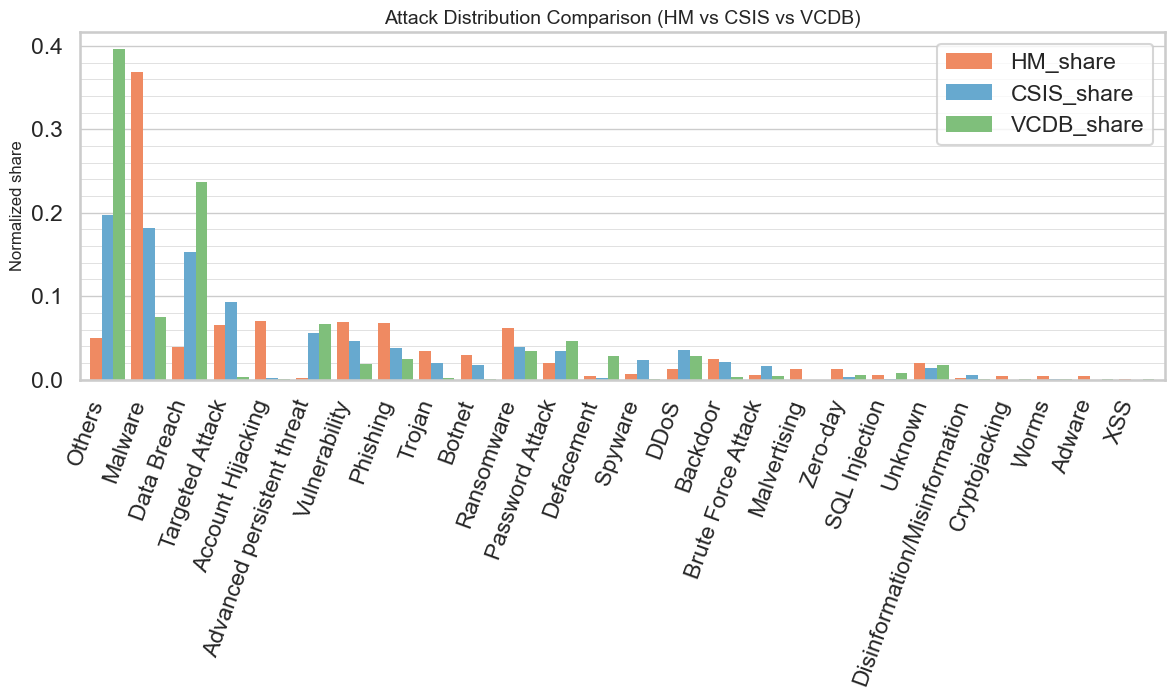

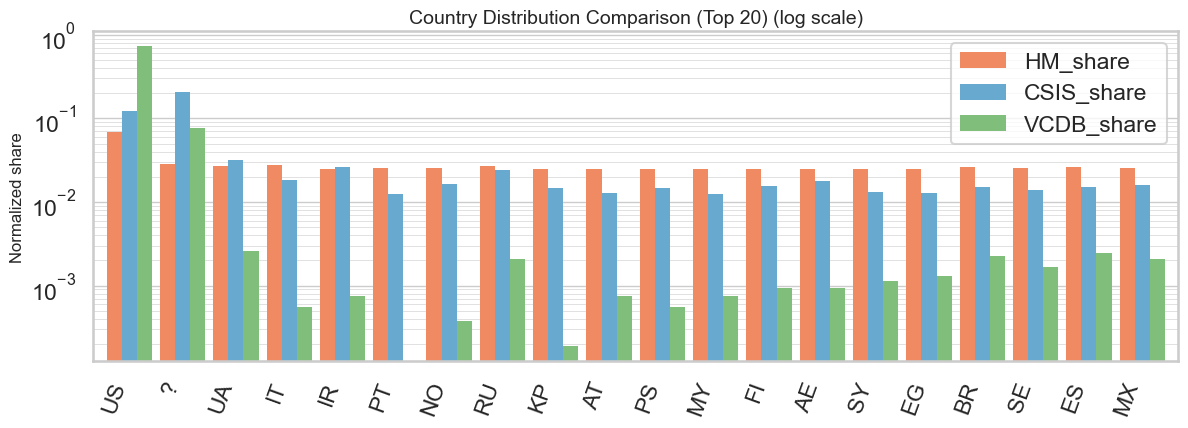

In [12]:
def grouped_bar_three(df, title, top_n=20, log_scale=False, base_figsize=(14, 5)):
    plot_df = df.sort_values("abs_diff", ascending=False).head(top_n).copy()
    share_cols = [c for c in plot_df.columns if c.endswith("_share")]
    plot_df = plot_df[share_cols]

    labels = [str(i) for i in plot_df.index]
    max_label_len = max((len(lbl) for lbl in labels), default=0)

    extra_height = min(4.0, max(0.0, (max_label_len - 12) * 0.08))
    fig_width, fig_height = base_figsize
    fig, ax = plt.subplots(figsize=(fig_width, fig_height + extra_height))

    color_map = {
        "HM_share": "#ef8a62",
        "CSIS_share": "#67a9cf",
        "VCDB_share": "#7fbf7b",
    }
    plot_colors = [color_map.get(c, "#999999") for c in share_cols]

    plot_df.plot(
        kind="bar",
        ax=ax,
        width=0.85,
        color=plot_colors,
        edgecolor="none",
        linewidth=0,
    )

    ax.set_title(title)
    ax.set_ylabel("Normalized share")
    ax.set_xlabel("")

    if log_scale:
        ax.set_yscale("log")
        ax.set_title(title + " (log scale)")

    ax.grid(False)
    ax.grid(axis="y", which="major", color="#cccccc", linewidth=1.0)
    ax.minorticks_on()
    ax.grid(axis="y", which="minor", color="#cccccc", linewidth=0.6, alpha=0.7)
    ax.grid(axis="x", which="both", visible=False)

    plt.xticks(rotation=70, ha="right")

    bottom_margin = min(0.55, 0.22 + max(0.0, (max_label_len - 10) * 0.006))
    fig.subplots_adjust(bottom=bottom_margin)
    plt.show()


grouped_bar_three(country_compare, "Country Distribution Comparison (HM vs CSIS vs VCDB)", top_n=1000)
grouped_bar_three(attack_compare, "Attack Distribution Comparison (HM vs CSIS vs VCDB)", top_n=len(attack_compare))

if len(country_compare) > 20:
    grouped_bar_three(country_compare, "Country Distribution Comparison (Top 20)", top_n=20, log_scale=True)